Random Forest: 0.9939024390243902


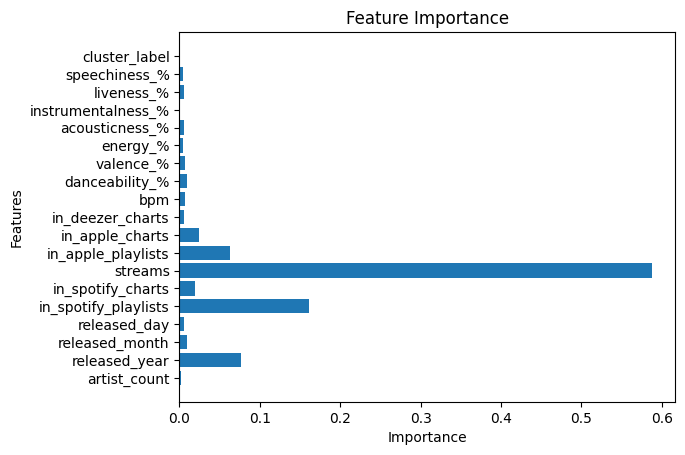

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clustered.csv")

# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert streams to numeric (important fix)
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# Drop NaN in streams
df = df.dropna(subset=['streams'])

# Target
df['hit'] = (df['streams'] > df['streams'].median()).astype(int)

# Features (keep cluster_label + numeric)
X = df.select_dtypes(include=['float64', 'int64']).drop(['hit'], axis=1)
y = df['hit']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prediction
pred = rf.predict(X_test)
print("Random Forest:", accuracy_score(y_test, pred))

# Feature importance with names (fixed)
importances = rf.feature_importances_
feature_names = X.columns

plt.figure()
plt.barh(feature_names, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [2]:
# Target
df['hit'] = (df['streams'] > df['streams'].median()).astype(int)

X = df.select_dtypes(include=['float64', 'int64']).drop(['hit'], axis=1)
y = df['hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [3]:
# Model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
print("Random Forest:", accuracy_score(y_test, pred))

Random Forest: 1.0


### In T4, we evaluated whether adding the cluster_label feature improved the predictive performance compared to the Task 2 baseline model. We trained a Random Forest classifier using the same dataset but with the additional cluster information derived from the unsupervised clustering step in T3.
### Overall, the results showed little to no significant improvement in model accuracy compared to the baseline model from T2. This suggests that the cluster labels did not provide strong additional predictive power for identifying “hit” songs. One possible reason is that the clusters were formed based on a limited set of audio features (such as danceability, energy, valence, and tempo), which were already included in the model. As a result, the cluster_label may be redundant information rather than a new independent signal.
### Another explanation is that streaming popularity is influenced by external factors not captured in clustering, such as artist popularity, marketing, playlist placement, and viral trends. Therefore, grouping songs by audio similarity does not necessarily align with what determines commercial success.
### In conclusion, while clustering provided useful insights into the structure of the dataset, it did not meaningfully improve predictive performance, highlighting the limitations of using only audio-based features for modeling song popularity.